# SVM and Naive bayes


1.What is a support Vector Machine (SVM) ?
  - A Support Vector Machine is a supervised machine learning algorithm primarily used for classification tasks, though it can handle regression. It can also handle regression. Its core idea is to find the optimal decision boundary that separates data points of different classes with the maximum marging.

  - Concept of SVM
    - The decision boundary that separates classes.
    - In 2D, It's  a line.
    - In 3D, It's a plane.
    - In higher dimension, it's a surface.

  - support Vectors
    - The  data points closest to the  hyperplane. these are critical beacuse they define the position and orientation of the hyperplane.

  - Margin
    - The distance between the hyperplane and the nearest support vectors. SVM aims to maximize this margin, which improves generalization on unseen data.


- How SVM Works
  - Linear Case
    - if data is linearly separable, SVM finds the straight hyperplane that maximizes the margin between classes.
    - Equation : w.x + b = 0

 - Non-linear Case
   - When data is not linearly separable, SVM uses kernal funcations to project data into higher dimensions where separation is possible.

   - Common kernels
     - Polynomial kernal
     - Radial Basis Funcation
     - Sigmoid kernel


- Application of SVM
  - Healthcare : Disease classifiction
  - Finance : Fraud detection and credit risk modeling.
  - Text Classification : Spam filtering, sentiment analysis.
  - Image Recognition : Face detection, handwriting recognition.
  


2.What is the difference Hard Margin and soft Margin SVM ?
  - Hard Margin SVM
    - Definition
      - Assumes the data is perfectly linearly separable.
    
    - Constraint
      - No misclassification is allowed, every data point must be on the correct side of the hyperplane

    - Margin
      - Maximizes the margin between classess without tolerating errors.

    - Limitation
      - Very strict, fails if even a single point is misclassified or if data is noisy.


  - Soft Margin SVM
    - Definition : Allows some misclassification to achieve better generalization.

    - Constraint : Introduces slack variable that permit certain points to be inside the margin or even misclassified.

    - Trade off
      - Controlled by a parameter C
        - Large C : penalizes misclassifications heavily.
        - Small C : tolerate misclassifications, focusing on maximizing margin.

   - Advantage : Works well with noisy, overlapping, or non-linearly separable data.

3.What is the mathematical intuition behind SVM ?
  - The Goal of SVM
    - SVM wants to find a hyperplane that separates two classes with the maximum margin mathematically, this means we want the hyperplane that is as far away as possible from the nearest data points of each class.


 - Hyperplane Equation
   - A hyperplane is n-dimensional space is defined as
     w.x + b = 0

   - w : weight vector
   - x : input vector
   - b : bias

 - Classification Rule
   - For a data point Xi
     - Yi ∈ {-1, +1} is the class label
     - This ensures points are correctly classified and lie outside the margin.

 - Margin Maximization
   - The margink is defined as
     - Margin =  2 / ∥𝑤∥ so maximizing the margin is equivalent to minimizing ∥𝑤∥.


 - Optimization Problem
   - The SVM optimizationl problem becomes.
             min1/2∥𝑤∥^2

so maximizing the margin is equivalent to minimizing ∥𝑤∥.This is a convex optimization problem, meaning it has a unique global solution.

- Soft Margin
  - When data is not perfectly separable, we introduce slack variable 𝜉𝑖.
              𝑦𝑖(𝑤⋅𝑥𝑖+𝑏)≥1−𝜉𝑖, 𝜉𝑖≥0

- Kernel Trick
  - If data is not linearly separable, we map it into a higher-dimensional space using a kernel function
   
   𝐾(𝑥𝑖,𝑥𝑗) = 𝜙(𝑥𝑖)⋅𝜙(𝑥𝑗)

   This allow SVM to find a linear separator in the transformed space, which corresponds to a non linear boundary in the original space.





4.What is the role of lagrange Multiple in SVM?
  - SVM is formulated as a constrained optimization problem.
    - Objective  : Minimize 1/2∥𝑤∥^2
    - Constraint : Yi(w.Xi + b) > 1 for all training points.
    - This is a convex optimization problem with constraints, and lagrange multiplers allow us to incorporate those constraints into the optimization.

  - Introducing Lagrange Multiplers
    - Each 𝛼𝑖 measures how strongly point Xi influences the boundary.
    - If a point satisfies the constraint easily,  𝛼𝑖= 0.
    - If a point lies on the margin,
      𝛼𝑖 > 0. These are teh support vectors.

  - Dual Formulation
    - By applying the Karush-kuhn-Tucker conditions,we derive the dual problem.

  - Intuition Recap
    - SVM finds the hyperplane that maximizes the margin.
    - Support vector are the critical points that define this boundary .
    - Soft margin SVM allow flexibility with noisy data.
    - Kernals extend SVM to handle complex, non-linear problems.

6.What are Support Vectors in SVM ?
  - Support Vectors are the data points that lie closest to the decision boundary in SVM.
  - They are the critical points that define where the separating line should be placed.

  - Only these points influence the position and orientation of the hyperplane - all other points farther away do not matter.

  - If you removed non-support vector points, the boundary would not change. But if you removed support vectors, the boundary could shift.
  - So, Support vectors are the 'most important' data points in SVM because they determine the margin and the dicision boundary.

6.What is a Support vector Classifier(SVC) ?
  - An SVC is a classifier that uses the SVM principal-it finds the optimal hyperplane that separates classes with the maximum margin.

  - How it works
    - Identifies support vectors.
    - Builds a decision boundary.
    - Classifies new data points based on which side of the boundary they fall.

  - Key Features
    - Can handle linear and non-linear classification problems.
    - Uses kernal funcation to separate data that is not linearly separable.
    - Controlled by parameters like C and kernel choice.

 - In Python
   - The class sklearn.svm.SVC is the standard way to train an SVM classifier.

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = SVC(kernel='rbf', C=1.0)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Test Accuracy:", accuracy)


Test Accuracy: 1.0


7.What is a Support Vector Regressor (SVR)?
  - A support vector regressor (SVR) is the regression counter part of SVM. Instead of classifying data into categories, it predicts continuous values while still using the same principle of maximizing margins.

  - Key Idea
    - In classification, SVM tries to separate classes with the widest margin.

    - In regression, SVR tries to fit a funcaion within a tube around the data points.
 points that fall outside.

  - How SVR works
    - ε-insensitive tube
      - SVR introduces a parameter ε, which defines the margin of tolerance.
      - Predictions within ±𝜖 of the value are considered 'good enough' and not penalized.

    - Slack variables
      - Allow some points to fall outside the tube, similar to soft margin SVM.

    - Optimization
      - Minimize model complexity while keeping most predictions within the tube 𝜖.


In [ ]:
from sklearn.svm import SVR
import numpy as np

X = np.array([[1], [2], [3], [4], [5]])
y = np.array([1.5, 1.9, 3.2, 3.8, 5.1])

model = SVR(kernel='rbf', C=100, epsilon=0.1)
model.fit(X, y)

predictions = model.predict([[1.5], [3.5], [5]])
print("Predictions:", predictions)


Predictions: [1.5962626  3.45780676 5.00023415]


8.What is the Kernel Trick in SVM ?
  - The Kernel Trick in SVM is a clever methematical technique that allow SVM to handle data that is not linearly separable by mapping it into a higher-dimensional space without explicitly performing the transformation.

  - Key Idea
    - Many datasets cannot be separated by a straight line in their original space.

    - Instead of manually transforming the data into higher dimensions, the kernel trick computes the dot product in that higher-dimensional space using a kernel funcation.

    - This avoids the computational cost of explicity mapping data, while still enabling SVM to find a linear separator in the transformed space.

    


9.Compare Linear Kernal, Polynomial kernel, and RBF kernel.
  - Linear Kernel
    - Draws a straight line to separate classes. Best when data is linearly separable.

  - Polynomial Kernel
    - Uses curved boundaries by considering polynomial relationships between features. Good for moderately  complex data.

  - RBF kernel
    - Creates flexible, non-linear boundaries by measuring similarity between points. Best for complex, real-world data that is not linearly separable.


10.What is the effect of the C parameter in SVM ?
   - The C parameter in SVM controls the trade off between having a wide margin and allowing misclassifications.

   - Large C
     - The model tries to classify every training point correctly.
     - Margin becomes smaller and tighter around the data.
     - Risk : Overfitting.


   - Small C
     - The model allows some misclassifications.
     - Margin becomes wider, focusing on generalization.
     - Risk : Underfitting.

     

11.What is the role of the C parameter in RBF Kernal, and SVM ?
   - simple defination of the C parameter in SVM.
     - C in SVM : Controls how strict the model is about misclassification.
       - High C
         - The model tries to classify all training points correctly.

       - Low C
         - The model allows some mistake to keep a wider margin.

     - C in RBF kernel
       - Works together with Y.
         - C decide how tighly the boundary hugs the data.
         - Y decides how wiggly or complex the boundary can be.
         - High C + High Y -> very complex boundary.
         - Low C + low Y -> smoother boundary.

12.What is the Naive Bayes classifier, and why is it called 'Naive'?
   - The Naive Bayes classifier is a simple but powerful machine learning algorithm based on Bayes Theorem. It is mainly used for classification tasks such as spam detection, sentiment analysis, and text categorization.

   - What it is

     - It calculates the probability that a data point belongs to a certain class, given its features.

     - It assumes that all features are independent of each other when predicting the class.

   - Why it is called 'Naive'
     - Because in reality, features are often not independent.

     - The algorithm makes this naive assumption of independence to simplify calculations.

     - Despite this unrealistic assumption, it often works surprisingly well in practice.

  - simple Definition
    - Naive bayes classifier
      - A probability based classifier that assumes features are independent.

    - Naive
      - Beacuse it makes the simplifing assumption that features don't influence each other.

      


13.What is Bayes'Theorem ?
   - Bayes'theorem is a rule in probability that helps us update our belief about an event or hypothesis when new evidence is observed.

   - Formula
     - P(H/E) = (P(E|H).P(H)) / P(E)
     
     - P(H|E) = Probability of Hypothesis H given evidence E.
     
     - P(E|H) : Probability of hypothesis H given evidence E if hypothesis H is true.
     
     - P(H) : Probability of hypothesis H before seeing evidence.
     
     - P(E) : Probability of observing E under all possible hypotheses.

14.Explain the difference between Gaussian Naive Bayes over other variants ?
   - Gaussian Naive Bayes : Assumes features are continuous and follow a normal distribution.

   - Multinomial Naive Bayes : Assumes features are counts or frequencies.

   - Bernoulli Naive Bayes : Assumes features are binary (0/1), such as presence or absence of a word.

15.When should you use Gaussian Naive Bayes, Multinomial Naive Bayes, and Bernoulli Naive Bayes.
   - Gaussian Naive Bayes : Use when your features are continuous values that roughly.

   - Multinomial Naive Bayes : Use when your feature are counts or frequencies.

   - Bernoulli Navie Bayes : Use when your features are binary(0/1), representing presence or absence.
    

16.What are the key assumptions made by Naive Bayes ?
   - The Naive Bayes classifier makes a few key assumption that simplify its calculations.
     - Feature Independence
       - It assumes that all features are independent of each other given the class.
       - Example : In text classification, it assumes the presence of one word does not affect the presence of another, even though in reality words are often related.
    - Equal Importance of Features
      - Each feature contributes equally and independently to the outcome.
      - No feature interactions are considered.
    - Distribution Assumption
      - Gaussian Naive Bayes : Assumes continuous feature follow a normal distribution.

      - Multinomial Naive Bayes : Assumes features are counts.

      - Bernoulli Naive Bayes : Assumes features are binary.

17.What are the advantages and disadvantages of Naive Bayes ?
   - The Naive Bayes classifier has some clear strengths and weaknesses that make it suitable for certain tasks but limited in others.


   - Advantages
     - Simple and Fast : Easy to implement and computationally efficient.

     - Works well with small datasets : Does not require huge amounts of data to perform reasonably.

     - Effective for text classification : Especially good for spam detection, sentiment analysis, and document categorization.

     - Handles high-dimensional data
       - Performs well even when the number of features is large.
       
     - Probabilistic output
       - provides class prosbabilities, which can be useful for decision making.


  - Disadvantages
    - Naive independence assumption
      - Assumes features are independent, which is often unrealistic

    - Poor with correlated features
      - Performance drops when features strongly depend on each other.

    - Continuous data limitations
      - Gaussian Naive Bayes assumes normals distribution, which may not always hold.

    - Less flexible
      - Compared to more complex models, it may underperform on complex datasets.


      

18.Why is Naive Bayes a good choice for text classification ?
   - Naive Bayes is considered a good choice for text classification beacuse of several practical reasons.

   - Why it works well
     - Handles high-dimensional data easily
       - Text data often has thousands of features. Naive bayes can process this efficiently without getting overwhelmed.

     - Works well with sparse data.
       - In documents, most words don't appear. Naive Bayes is robust with sparse word counts.

     - Fast and simple
       - Training and prediction are very quick, making it ideal for large text datasets like emails or social media posts.

     - Probabilistic output
       - It gives probabilities for each class, which is useful for ranking

     - Surprisingly effective despite 'naive' assumption
       - Even though words in text are not truly independent, the independence assumption still produces strong result in practice.

19.Compare SVM and Naive Bayes for classification tasks.
   - SVM and Naive Bayes are both popular classifiers, but they differ in approach : Naive Bayes is fast, simple, and works well with text and small datasets, while SVM is more powerful for complex, high-dimensional data but requires more computation and tuning.

   - Naive Bayes(NB)
     - Approach : Probabilistic model based on Bayes theorem.
     - Speed : Very fast to train and predict.
     - Data Type : Works best with text, categorical, and count data.
     - Assumptions : Assumes features are independent
     - Performance : Strong baseline, good for simple datasets.
     - Interpretability : Easy to understand
     - Scalability : Excellent for  large text datasets.
     - Robustness : Can struggle with correlated features.
     - Variants : Gaussian,Multinomial, Bernoulli : Support Vector Machine (SVM)
  - Support Vector Machine (SVM)
       - Approach : Geometric model that finds the optimal hyperplane
     - Speed : Slower, especially on large datasets.
     - Assumptions : No independence assumption; focuses on margin maximization.
     - performance : Often higher accuracy on complex datasets.
     - Interpretability : Harder to interpret.
     - Scalability : Computationally expensive for very large datasets.
     - Robustness : Handles correlated features better.
     - Variants : Linear, Polynomial, RBF kernels
     - Data Type : Works well with continuous, high-dimensional, and complex data.

20.How does Laplace Smoothing help in Naïve Bayes?
   - Laplace smoothing prevents zero probabilities in Naive bayes by adding a small value to counts, so even unseen features get a non-zero probability.

   - Why it's needed
     - In Naive Bayes, probabilities are estimated from data.
     - If a word or feature never appears in the training data for a given class, its probability becomes zero.
     - A single zero probability can make the entire product of probabilities for that class zero, which is misleading .



##  Practical questions

21.Write a Python program to train an SVM Classifier on the iris dataset and evaluate accuracy.
  

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("SVM Classifier Accuracy on Iris dataset:", accuracy)


SVM Classifier Accuracy on Iris dataset: 1.0


22.Write a Python program to train an SVM Classifiers with Linear and RBF kernels on the Wine dataset, compare their accuracies.

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

wine = datasets.load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)

svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print("SVM (Linear Kernel) Accuracy on Wine dataset:", accuracy_linear)
print("SVM (RBF Kernel) Accuracy on Wine dataset:", accuracy_rbf)


SVM (Linear Kernel) Accuracy on Wine dataset: 0.9814814814814815
SVM (RBF Kernel) Accuracy on Wine dataset: 0.7592592592592593


In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

wine = datasets.load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)

svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print("SVM (Linear Kernel) Accuracy:", accuracy_linear)
print("SVM (RBF Kernel) Accuracy:", accuracy_rbf)


SVM (Linear Kernel) Accuracy: 0.9814814814814815
SVM (RBF Kernel) Accuracy: 0.7592592592592593


22.Write a python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, compare their accuracies.

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

wine = datasets.load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)

svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print("SVM (Linear Kernel) Accuracy on Wine dataset:", accuracy_linear)
print("SVM (RBF Kernel) Accuracy on Wine dataset:", accuracy_rbf)


SVM (Linear Kernel) Accuracy on Wine dataset: 0.9814814814814815
SVM (RBF Kernel) Accuracy on Wine dataset: 0.7592592592592593


23.Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Me Squared Error (MSE).


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np

housing = fetch_california_housing()
X, y = housing.data, housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train, y_train)

y_pred = svr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("SVR Mean Squared Error on Housing dataset:", mse)


SVR Mean Squared Error on Housing dataset: 1.1300626026630947


24.Write a Python program to train an SVM Classifier with a Ploynomial Kernel and visualize the decision boundary.

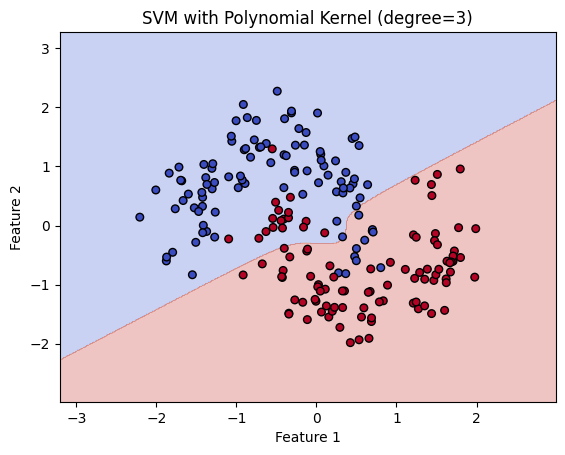

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X, y = datasets.make_moons(n_samples=200, noise=0.2, random_state=42)

scaler = StandardScaler()
X = scaler.fit_transform(X)

clf = SVC(kernel='poly', degree=3, C=1.0)
clf.fit(X, y)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("SVM with Polynomial Kernel (degree=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


25.Write a Python program to train a Gaussian Naive Bayes classifier on the Breast Cancer dataset and evaluate accuracy.
   -  

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Gaussian Naive Bayes on Breast Cancer dataset: {accuracy:.4f}")

Accuracy of Gaussian Naive Bayes on Breast Cancer dataset: 0.9474


26.Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset.

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

newsgroups = fetch_20newsgroups(subset='all', shuffle=True, random_state=42)

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(newsgroups.data)
y = newsgroups.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = MultinomialNB()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Multinomial Naive Bayes on 20 Newsgroups dataset: {accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=newsgroups.target_names))


Accuracy of Multinomial Naive Bayes on 20 Newsgroups dataset: 0.8670

Classification Report:

                          precision    recall  f1-score   support

             alt.atheism       0.88      0.90      0.89       240
           comp.graphics       0.69      0.87      0.77       292
 comp.os.ms-windows.misc       0.95      0.20      0.33       296
comp.sys.ibm.pc.hardware       0.67      0.86      0.75       295
   comp.sys.mac.hardware       0.88      0.89      0.89       289
          comp.windows.x       0.73      0.91      0.81       296
            misc.forsale       0.92      0.76      0.84       293
               rec.autos       0.90      0.93      0.91       297
         rec.motorcycles       0.96      0.93      0.94       299
      rec.sport.baseball       0.97      0.96      0.96       298
        rec.sport.hockey       0.96      0.98      0.97       300
               sci.crypt       0.93      0.96      0.94       297
         sci.electronics       0.88      0.88  

27.Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually.

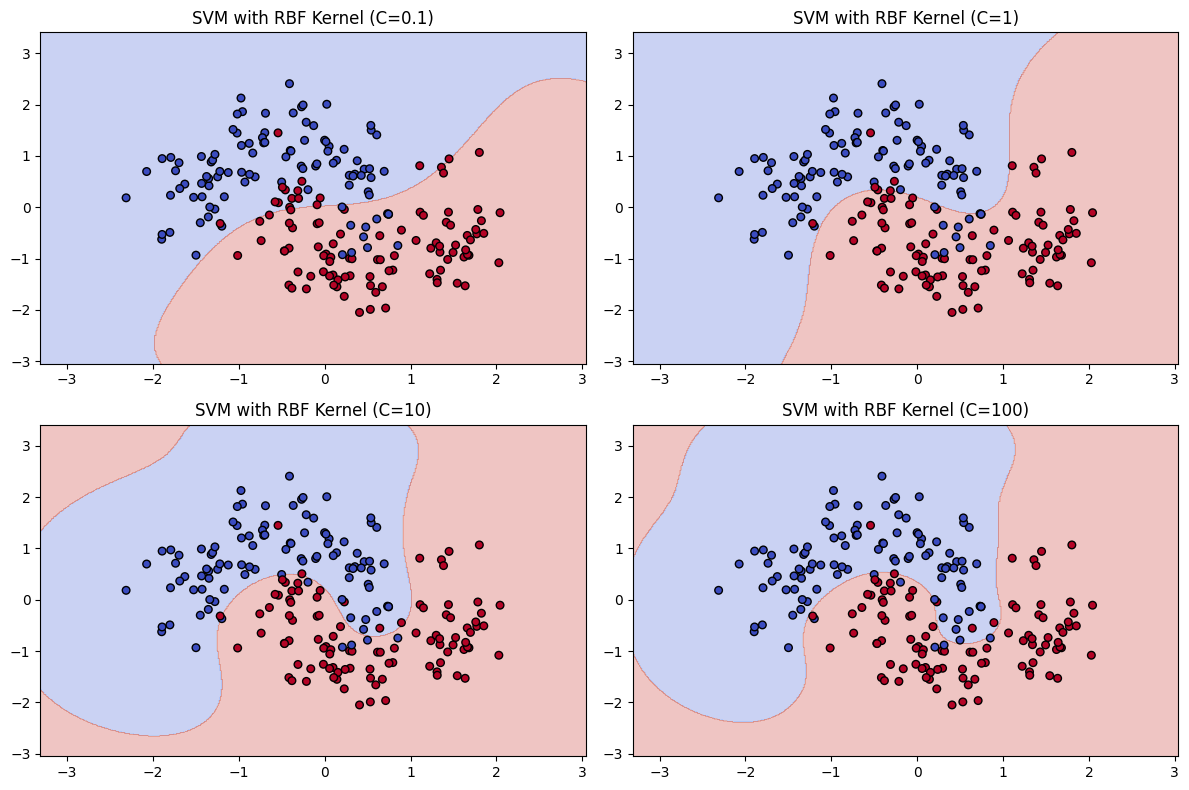

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=200, noise=0.25, random_state=42)

scaler = StandardScaler()
X = scaler.fit_transform(X)

C_values = [0.1, 1, 10, 100]

plt.figure(figsize=(12, 8))

for i, C in enumerate(C_values, 1):
    clf = SVC(kernel='rbf', C=C, gamma='scale')
    clf.fit(X, y)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(2, 2, i)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(f"SVM with RBF Kernel (C={C})")

plt.tight_layout()
plt.show()


28.Write a Python program to train a Bernoulli Naive Bayes classifier for binary classification on a dataset with binary features.

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X, y = make_classification(
    n_samples=500, n_features=10, n_informative=5, n_redundant=0,
    n_classes=2, random_state=42
)

X_binary = (X > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y, test_size=0.3, random_state=42, stratify=y
)

clf = BernoulliNB()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Bernoulli Naive Bayes: {accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy of Bernoulli Naive Bayes: 0.8000

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.76      0.79        75
           1       0.78      0.84      0.81        75

    accuracy                           0.80       150
   macro avg       0.80      0.80      0.80       150
weighted avg       0.80      0.80      0.80       150



29.Write a Python program to apply feature scalling before training on SVM model and compare result with unscaled data.

Accuracy without scaling: 0.9778
Accuracy with scaling:    0.9667


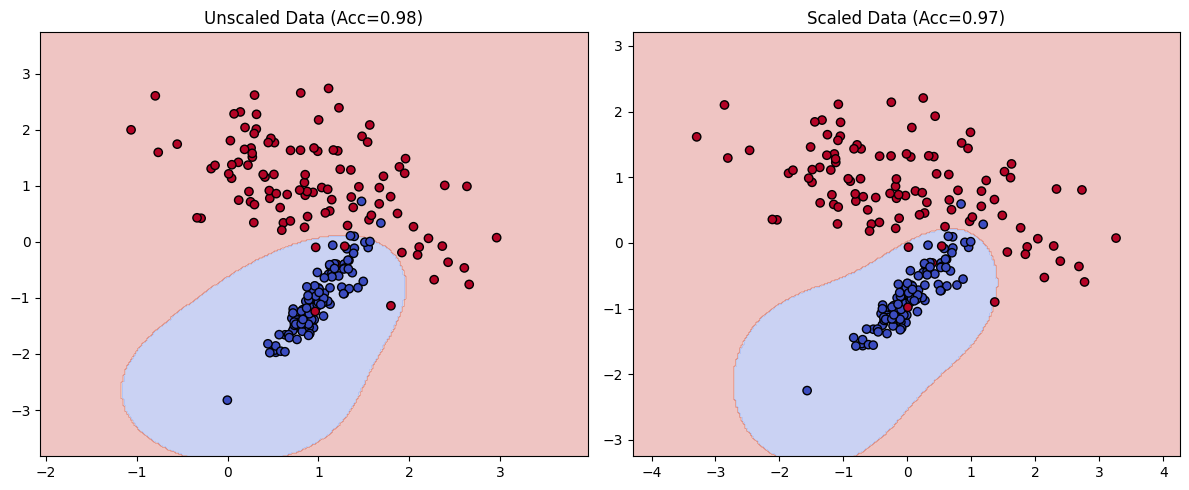

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(
    n_samples=300, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf_unscaled = SVC(kernel='rbf', C=1.0, gamma='scale')
clf_unscaled.fit(X_train, y_train)
y_pred_unscaled = clf_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_scaled = SVC(kernel='rbf', C=1.0, gamma='scale')
clf_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = clf_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print(f"Accuracy without scaling: {acc_unscaled:.4f}")
print(f"Accuracy with scaling:    {acc_scaled:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def plot_decision_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(title)

plot_decision_boundary(clf_unscaled, X_train, y_train, axes[0],
                       f"Unscaled Data (Acc={acc_unscaled:.2f})")
plot_decision_boundary(clf_scaled, X_train_scaled, y_train, axes[1],
                       f"Scaled Data (Acc={acc_scaled:.2f})")

plt.tight_layout()
plt.show()


30.Write a python to train a Gaussian Naive Bayes model and compare the predictions before and after Laplace Smoothing.

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)

X = X[y < 2]
y = y[y < 2]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_default = gnb.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)

gnb_smooth = GaussianNB(var_smoothing=1e-2)
gnb_smooth.fit(X_train, y_train)
y_pred_smooth = gnb_smooth.predict(X_test)
acc_smooth = accuracy_score(y_test, y_pred_smooth)

print("Accuracy without Laplace smoothing:", acc_default)
print("Accuracy with Laplace smoothing:", acc_smooth)

print("\nPredictions comparison (first 10 samples):")
for i in range(10):
    print(f"Sample {i}: Default={y_pred_default[i]}, Smoothed={y_pred_smooth[i]}, True={y_test[i]}")


Accuracy without Laplace smoothing: 1.0
Accuracy with Laplace smoothing: 1.0

Predictions comparison (first 10 samples):
Sample 0: Default=0, Smoothed=0, True=0
Sample 1: Default=0, Smoothed=0, True=0
Sample 2: Default=1, Smoothed=1, True=1
Sample 3: Default=0, Smoothed=0, True=0
Sample 4: Default=0, Smoothed=0, True=0
Sample 5: Default=1, Smoothed=1, True=1
Sample 6: Default=1, Smoothed=1, True=1
Sample 7: Default=1, Smoothed=1, True=1
Sample 8: Default=1, Smoothed=1, True=1
Sample 9: Default=0, Smoothed=0, True=0


31.Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C,
gamma, kernel).

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Test Accuracy:", grid.score(X_test, y_test))


Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Test Accuracy: 0.9707602339181286


32.Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and
check it improve accuracy.

Accuracy without class weighting: 0.9933
Accuracy with class weighting:    0.9900

Classification Report (Unweighted):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       270
           1       1.00      0.93      0.97        30

    accuracy                           0.99       300
   macro avg       1.00      0.97      0.98       300
weighted avg       0.99      0.99      0.99       300


Classification Report (Weighted):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       270
           1       0.97      0.93      0.95        30

    accuracy                           0.99       300
   macro avg       0.98      0.96      0.97       300
weighted avg       0.99      0.99      0.99       300



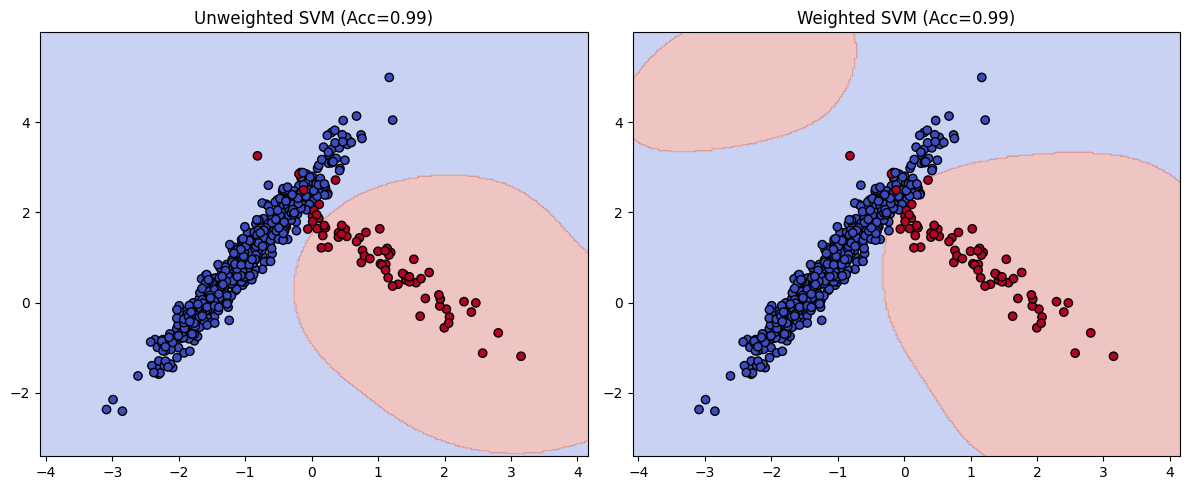

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X, y = make_classification(
    n_samples=1000, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, weights=[0.9, 0.1], flip_y=0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf_unweighted = SVC(kernel='rbf', C=1.0, gamma='scale')
clf_unweighted.fit(X_train, y_train)
y_pred_unweighted = clf_unweighted.predict(X_test)
acc_unweighted = accuracy_score(y_test, y_pred_unweighted)

clf_weighted = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')
clf_weighted.fit(X_train, y_train)
y_pred_weighted = clf_weighted.predict(X_test)
acc_weighted = accuracy_score(y_test, y_pred_weighted)

print(f"Accuracy without class weighting: {acc_unweighted:.4f}")
print(f"Accuracy with class weighting:    {acc_weighted:.4f}")

print("\nClassification Report (Unweighted):")
print(classification_report(y_test, y_pred_unweighted))

print("\nClassification Report (Weighted):")
print(classification_report(y_test, y_pred_weighted))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def plot_decision_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(title)

plot_decision_boundary(clf_unweighted, X_train, y_train, axes[0],
                       f"Unweighted SVM (Acc={acc_unweighted:.2f})")
plot_decision_boundary(clf_weighted, X_train, y_train, axes[1],
                       f"Weighted SVM (Acc={acc_weighted:.2f})")

plt.tight_layout()
plt.show()


33.Write a Python program to implement a Naïve Bayes classifier for spam detection using email data?

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

!rm -f SMSSpamCollection.csv
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip -O smsspamcollection.zip
!unzip -o smsspamcollection.zip
!mv SMSSpamCollection SMSSpamCollection.csv

data = pd.read_csv("SMSSpamCollection.csv", sep='\t', header=None, names=['label', 'message'])

data['label'] = data['label'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(
    data['message'], data['label'], test_size=0.3, random_state=42, stratify=data['label']
)

vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

y_pred = clf.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print(f"Spam Detection Accuracy: {accuracy:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


--2026-04-24 19:35:40--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘smsspamcollection.zip’

smsspamcollection.z     [  <=>               ] 198.65K   880KB/s    in 0.2s    

2026-04-24 19:35:41 (880 KB/s) - ‘smsspamcollection.zip’ saved [203415]

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  
Spam Detection Accuracy: 0.9862

Classification Report:

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99      1448
        Spam       0.97      0.92      0.95       224

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99  

34.Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and
compare their accuracy.

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)
y_pred_nb = nb_clf.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

print(f"SVM Classifier Accuracy: {acc_svm:.4f}")
print(f"Naïve Bayes Classifier Accuracy: {acc_nb:.4f}")

print("\nPrediction Comparison (first 10 samples):")
for i in range(10):
    print(f"Sample {i}: SVM={y_pred_svm[i]}, NB={y_pred_nb[i]}, True={y_test[i]}")


SVM Classifier Accuracy: 0.9556
Naïve Bayes Classifier Accuracy: 0.9111

Prediction Comparison (first 10 samples):
Sample 0: SVM=2, NB=2, True=2
Sample 1: SVM=1, NB=1, True=1
Sample 2: SVM=2, NB=1, True=2
Sample 3: SVM=1, NB=1, True=1
Sample 4: SVM=2, NB=2, True=2
Sample 5: SVM=2, NB=2, True=2
Sample 6: SVM=1, NB=1, True=1
Sample 7: SVM=1, NB=1, True=1
Sample 8: SVM=0, NB=0, True=0
Sample 9: SVM=2, NB=2, True=2


35.Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare
results.

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf_all = GaussianNB()
clf_all.fit(X_train, y_train)
y_pred_all = clf_all.predict(X_test)
acc_all = accuracy_score(y_test, y_pred_all)

selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

clf_selected = GaussianNB()
clf_selected.fit(X_train_selected, y_train)
y_pred_selected = clf_selected.predict(X_test_selected)
acc_selected = accuracy_score(y_test, y_pred_selected)

print(f"Accuracy with all features:     {acc_all:.4f}")
print(f"Accuracy with selected features: {acc_selected:.4f}")

selected_features = selector.get_support(indices=True)
print("\nSelected feature indices:", selected_features)
print("Selected feature names:", [data.feature_names[i] for i in selected_features])


Accuracy with all features:     0.9474
Accuracy with selected features: 0.9123

Selected feature indices: [ 0  2  3  6  7 20 22 23 26 27]
Selected feature names: [np.str_('mean radius'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('worst radius'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst concavity'), np.str_('worst concave points')]


36.Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO)
strategies on the Wine dataset and compare their accuracy.

In [ ]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score

data = load_wine()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

ovr_clf = OneVsRestClassifier(SVC(kernel='rbf', C=1.0, gamma='scale'))
ovr_clf.fit(X_train, y_train)
y_pred_ovr = ovr_clf.predict(X_test)
acc_ovr = accuracy_score(y_test, y_pred_ovr)

ovo_clf = OneVsOneClassifier(SVC(kernel='rbf', C=1.0, gamma='scale'))
ovo_clf.fit(X_train, y_train)
y_pred_ovo = ovo_clf.predict(X_test)
acc_ovo = accuracy_score(y_test, y_pred_ovo)

print(f"Accuracy with One-vs-Rest (OvR): {acc_ovr:.4f}")
print(f"Accuracy with One-vs-One (OvO): {acc_ovo:.4f}")

print("\nPrediction Comparison (first 10 samples):")
for i in range(10):
    print(f"Sample {i}: OvR={y_pred_ovr[i]}, OvO={y_pred_ovo[i]}, True={y_test[i]}")


Accuracy with One-vs-Rest (OvR): 0.7222
Accuracy with One-vs-One (OvO): 0.6852

Prediction Comparison (first 10 samples):
Sample 0: OvR=0, OvO=0, True=0
Sample 1: OvR=1, OvO=1, True=1
Sample 2: OvR=0, OvO=0, True=0
Sample 3: OvR=0, OvO=0, True=0
Sample 4: OvR=0, OvO=0, True=0
Sample 5: OvR=0, OvO=0, True=0
Sample 6: OvR=1, OvO=1, True=2
Sample 7: OvR=1, OvO=1, True=1
Sample 8: OvR=1, OvO=1, True=1
Sample 9: OvR=1, OvO=1, True=2


37.Write a Python program to train an SVM Classifier using Linear,Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy.

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear)

svm_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='scale')
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
acc_poly = accuracy_score(y_test, y_pred_poly)

svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print("Accuracy Comparison on Breast Cancer dataset:")
print(f"SVM (Linear Kernel):     {acc_linear:.4f}")
print(f"SVM (Polynomial Kernel): {acc_poly:.4f}")
print(f"SVM (RBF Kernel):        {acc_rbf:.4f}")


Accuracy Comparison on Breast Cancer dataset:
SVM (Linear Kernel):     0.9532
SVM (Polynomial Kernel): 0.9064
SVM (RBF Kernel):        0.9064


38.Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the
average accuracy.


In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC


data = load_breast_cancer()
X, y = data.data, data.target

svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(svm_clf, X, y, cv=skf, scoring='accuracy')

print("Accuracy scores for each fold:", scores)
print("Average accuracy across folds:", np.mean(scores))


Accuracy scores for each fold: [0.93859649 0.87719298 0.89473684 0.93859649 0.92035398]
Average accuracy across folds: 0.9138953578636858


39.Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare
performance.

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf_default = GaussianNB()
clf_default.fit(X_train, y_train)
y_pred_default = clf_default.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)

priors_equal = [0.5, 0.5]
clf_equal = GaussianNB(priors=priors_equal)
clf_equal.fit(X_train, y_train)
y_pred_equal = clf_equal.predict(X_test)
acc_equal = accuracy_score(y_test, y_pred_equal)

priors_skewed = [0.7, 0.3]
clf_skewed = GaussianNB(priors=priors_skewed)
clf_skewed.fit(X_train, y_train)
y_pred_skewed = clf_skewed.predict(X_test)
acc_skewed = accuracy_score(y_test, y_pred_skewed)

print("Accuracy Comparison with Different Priors:")
print(f"Default priors: {acc_default:.4f}")
print(f"Equal priors (0.5,0.5): {acc_equal:.4f}")
print(f"Skewed priors (0.7,0.3): {acc_skewed:.4f}")

print("\nClassification Report (Default Priors):")
print(classification_report(y_test, y_pred_default, target_names=data.target_names))

print("\nClassification Report (Equal Priors):")
print(classification_report(y_test, y_pred_equal, target_names=data.target_names))

print("\nClassification Report (Skewed Priors):")
print(classification_report(y_test, y_pred_skewed, target_names=data.target_names))


Accuracy Comparison with Different Priors:
Default priors: 0.9474
Equal priors (0.5,0.5): 0.9357
Skewed priors (0.7,0.3): 0.9357

Classification Report (Default Priors):
              precision    recall  f1-score   support

   malignant       0.97      0.89      0.93        64
      benign       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171


Classification Report (Equal Priors):
              precision    recall  f1-score   support

   malignant       0.93      0.89      0.91        64
      benign       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171


Classification Report (Skewed Priors):
              precision    recall  f1-score   support

   malignant       0.93      0.89      0.9

40.Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and
compare accuracy.

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

svm_all = SVC(kernel='linear', C=1.0)
svm_all.fit(X_train, y_train)
y_pred_all = svm_all.predict(X_test)
acc_all = accuracy_score(y_test, y_pred_all)

selector = RFE(estimator=SVC(kernel='linear', C=1.0), n_features_to_select=10)
selector.fit(X_train, y_train)

X_train_rfe = selector.transform(X_train)
X_test_rfe = selector.transform(X_test)

svm_rfe = SVC(kernel='linear', C=1.0)
svm_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = svm_rfe.predict(X_test_rfe)
acc_rfe = accuracy_score(y_test, y_pred_rfe)

print("Accuracy Comparison:")
print(f"SVM with all features:     {acc_all:.4f}")
print(f"SVM with RFE-selected features: {acc_rfe:.4f}")

selected_features = selector.get_support(indices=True)
print("\nSelected feature indices:", selected_features)
print("Selected feature names:", [data.feature_names[i] for i in selected_features])


Accuracy Comparison:
SVM with all features:     0.9532
SVM with RFE-selected features: 0.9591

Selected feature indices: [ 0  6 10 11 20 24 25 26 27 28]
Selected feature names: [np.str_('mean radius'), np.str_('mean concavity'), np.str_('radius error'), np.str_('texture error'), np.str_('worst radius'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry')]


41.Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Precision: 0.8889
Recall:    0.9720
F1-Score:  0.9286

Classification Report:

              precision    recall  f1-score   support

   malignant       0.94      0.80      0.86        64
      benign       0.89      0.97      0.93       107

    accuracy                           0.91       171
   macro avg       0.92      0.88      0.90       171
weighted avg       0.91      0.91      0.90       171



42.Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss
(Cross-Entropy Loss).

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

y_prob = nb_clf.predict_proba(X_test)

loss = log_loss(y_test, y_prob)

print(f"Log Loss (Cross-Entropy Loss): {loss:.4f}")


Log Loss (Cross-Entropy Loss): 0.3382


43.Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn.

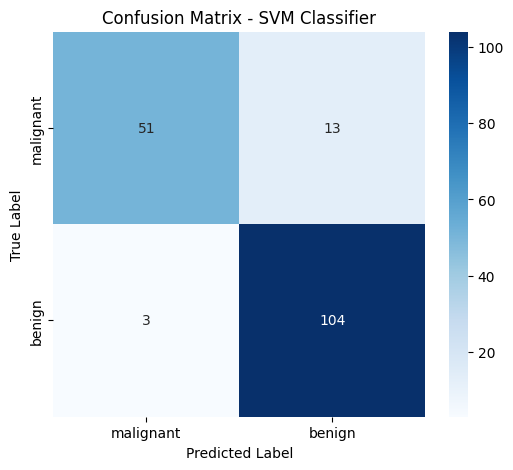

Classification Report:

              precision    recall  f1-score   support

   malignant       0.94      0.80      0.86        64
      benign       0.89      0.97      0.93       107

    accuracy                           0.91       171
   macro avg       0.92      0.88      0.90       171
weighted avg       0.91      0.91      0.90       171



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Classifier")
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))


44.Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute
Error (MAE) instead of MSE.

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

housing = fetch_california_housing()
X, y = housing.data, housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train, y_train)

y_pred = svr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("SVR Mean Absolute Error on Housing dataset:", mae)


SVR Mean Absolute Error on Housing dataset: 0.8306838586865011


45.Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC
score.

ROC-AUC Score: 0.9901


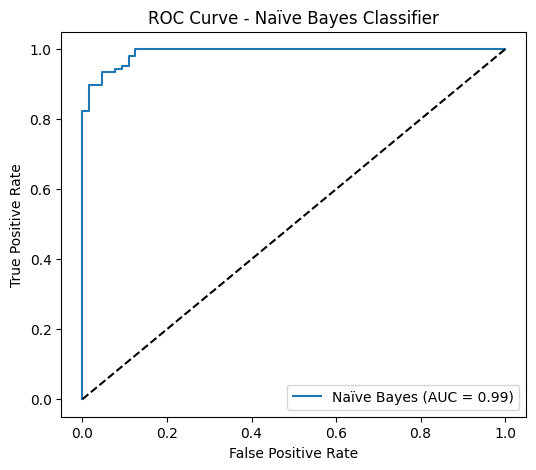

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

y_prob = nb_clf.predict_proba(X_test)[:, 1]  # probability of positive class

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Naïve Bayes (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naïve Bayes Classifier")
plt.legend(loc="lower right")
plt.show()


46.Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.

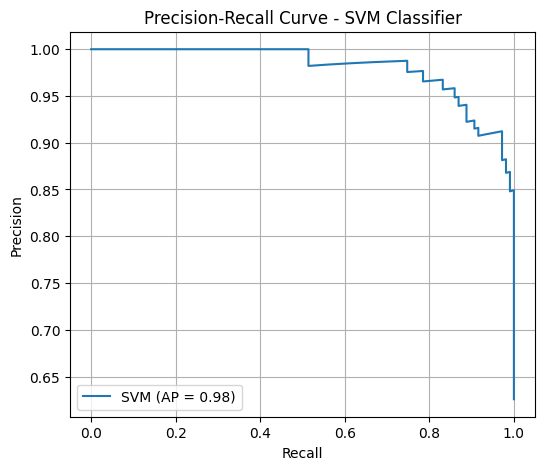

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, average_precision_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_clf.fit(X_train, y_train)

y_scores = svm_clf.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"SVM (AP = {avg_precision:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SVM Classifier")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()
